<a href="https://colab.research.google.com/github/Irwing18/Parte-pr-ctica-2/blob/main/tarea2_estadistica_completa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TAREA 2 — MODELOS DE REGRESIÓN EN PYTHON
**Universidad Industrial de Santander · Estadística II**

**Variable respuesta:** `ESTU_INSE_INDIVIDUAL` — Índice de nivel socioeconómico individual del estudiante evaluado en las pruebas Saber 11 (cohorte 2023-1). Este índice es calculado por el ICFES a partir de información del hogar del estudiante (estrato, ingresos familiares, acceso a bienes y servicios, educación de los padres) y se utiliza como proxy del capital socioeconómico familiar.

**Variables explicativas candidatas:**
- `PUNT_LECTURA_CRITICA`: Puntaje en el área de Lectura Crítica (escala 0–100)
- `PUNT_MATEMATICAS`: Puntaje en el área de Matemáticas (escala 0–100)
- `PUNT_C_NATURALES`: Puntaje en el área de Ciencias Naturales (escala 0–100)
- `PUNT_SOCIALES_CIUDADANAS`: Puntaje en el área de Sociales y Ciudadanas (escala 0–100)
- `PUNT_INGLES`: Puntaje en el área de Inglés (escala 0–100)

**Objetivo:** Seleccionar las variables más explicativas, ajustar un modelo de regresión lineal múltiple y una red neuronal multicapa, comparar su desempeño e imputar los valores faltantes de `ESTU_INSE_INDIVIDUAL`.

## 1. Importación de librerías

In [ ]:
import io
import pandas as pd #Con esto llevamos conjuntos o bases de datos a dataframes
import matplotlib.pyplot as plt #Con esto se grafican los diagramas de dispersión y demás gráficas
import numpy as np #Sirve para llevar columnas de tablas a arrays
import seaborn as sns #Sirve para visualizar datos estadísticos
from sklearn.model_selection import train_test_split #Usaremos la función "train_test_split" de la librería "sklearn" para poder escoger
#un conjunto de datos de entrenamiento y otro de validación por cross validation
from sklearn.linear_model import LinearRegression #Modelo lineal
from mpl_toolkits.mplot3d import Axes3D #Se usará para graficar el diagrama de dispersión
from scipy.stats import spearmanr, kendalltau #Se usa para calcular los coeficientes de correlación entre variables aleatorias
from sklearn.neural_network import MLPRegressor #para importar el modelo de la red neuronal
from sklearn.metrics import mean_squared_error, mean_absolute_error #Sirve para importar funciones que determinan la eficiencia del modelo

Librerías importadas correctamente.


## 2. Carga de la base de datos ICFES Saber 11 — 2023-1


In [ ]:
from google.colab import files  # Para cargar archivos en Google Colab
uploaded = files.upload() #Con esta función se carga el archivo

datos_icfes = pd.read_csv(
    io.BytesIO(uploaded['SB11_20231.TXT']),
    delimiter='¬' #Llevamos el archivo a un dataframe de pandas, que es como una tabla
)
print(f"Dimensiones del dataset: {datos_icfes.shape[0]:,} filas × {datos_icfes.shape[1]} columnas")
datos_icfes.head(5) #para imprimir el tamaño del dataset

Saving SB11_20231.TXT to SB11_20231.TXT


/tmp/ipykernel_1067/643325768.py:4: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  datos_icfes = pd.read_csv(


Dimensiones del dataset: 12,704 filas × 83 columnas


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
1,TI,COLOMBIA,M,08/04/2007,20231,SB11202310017318,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,326,NaN,47.223972,2.0,3,100.0,PUBLICAR
2,TI,COLOMBIA,F,26/05/2006,20231,SB11202310030916,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,186,NaN,67.695519,4.0,3,40.0,PUBLICAR
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR
4,TI,COLOMBIA,F,04/05/2005,20231,SB11202310044933,ESTUDIANTE,COLOMBIA,VALLE,76,...,69.0,57.0,B1,263,39.0,51.223795,3.0,3,92.0,PUBLICAR


## 3. Eliminación de valores faltantes (NaN)

Antes de construir cualquier modelo estadístico es indispensable tratar los valores faltantes. En el contexto del ICFES, los valores `NaN` aparecen cuando un estudiante no presentó alguna de las pruebas (por ejemplo, por inasistencia, invalidación del examen o porque la aplicación fue especial). Incluirlos en el ajuste del modelo introduciría sesgos y haría imposible el cálculo matricial de los coeficientes.

La estrategia elegida es la **eliminación por lista** (*listwise deletion*): se conservan únicamente los registros que tienen valor válido en *todas* las variables de interés. Esta es la práctica recomendada cuando la proporción de datos faltantes es pequeña y puede asumirse que la ausencia es aleatoria (MCAR o MAR).

In [ ]:
icfes_sin_nan = datos_icfes[
    (~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
]
#Esto sirve para elimnar los valores faltantes de cada una de las variables

n_total = len(datos_icfes)
n_sin_nan = len(icfes_sin_nan)
n_eliminados = n_total - n_sin_nan
print(f"Registros totales:         {n_total:>10,}")
print(f"Registros sin NaN:         {n_sin_nan:>10,}")
print(f"Registros eliminados:      {n_eliminados:>10,} ({100*n_eliminados/n_total:.1f}%)")
icfes_sin_nan.head() #Revisamos que ya no aparezcan los valores faltantes

Registros totales:             12,704
Registros sin NaN:             11,853
Registros eliminados:             851 (6.7%)


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR
4,TI,COLOMBIA,F,04/05/2005,20231,SB11202310044933,ESTUDIANTE,COLOMBIA,VALLE,76,...,69.0,57.0,B1,263,39.0,51.223795,3.0,3,92.0,PUBLICAR
5,TI,COLOMBIA,M,03/06/2005,20231,SB11202310029637,ESTUDIANTE,COLOMBIA,LA GUAJIRA,44,...,45.0,19.0,A-,271,43.0,57.690401,3.0,3,93.0,PUBLICAR
6,TI,COLOMBIA,F,23/08/2005,20231,SB11202310026848,ESTUDIANTE,COLOMBIA,VALLE,76,...,50.0,29.0,A1,295,54.0,39.984838,1.0,3,94.0,PUBLICAR


**Interpretación:** Se eliminaron los registros que no tenían información completa en al menos una de las seis variables de trabajo. La proporción de registros eliminados indica si la pérdida es relevante. Dado que los datos faltantes están asociados principalmente a estudiantes que no presentaron algún módulo (situación documentada por el ICFES), se asume que la eliminación no introduce un sesgo sistemático grave en el conjunto restante.

## 4. Estadísticas descriptivas de las variables de interés

In [ ]:
variables = [
    'ESTU_INSE_INDIVIDUAL',
    'PUNT_LECTURA_CRITICA',
    'PUNT_MATEMATICAS',
    'PUNT_C_NATURALES',
    'PUNT_SOCIALES_CIUDADANAS',
    'PUNT_INGLES'
]#Creamos la tabla con las variables con las que vamos a trabajar, se enlistan las columnas para hacer una subtabla de la tabla original
tabla_regresion = icfes_sin_nan[variables].copy()


print("Estadísticas descriptivas:")
tabla_regresion.describe().round(2)

Estadísticas descriptivas:


,ESTU_INSE_INDIVIDUAL,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES
count,11853.00,11853.00,11853.00,11853.00,11853.00,11853.00
mean,63.01,64.62,64.23,61.20,61.02,73.11
std,7.43,9.23,11.84,10.22,11.06,13.93
min,23.42,25.00,16.00,27.00,24.00,26.00
25%,58.19,59.00,57.00,55.00,54.00,64.00
50%,63.99,66.00,65.00,62.00,62.00,77.00
75%,68.54,71.00,72.00,69.00,69.00,82.00
max,83.01,100.00,100.00,100.00,100.00,100.00


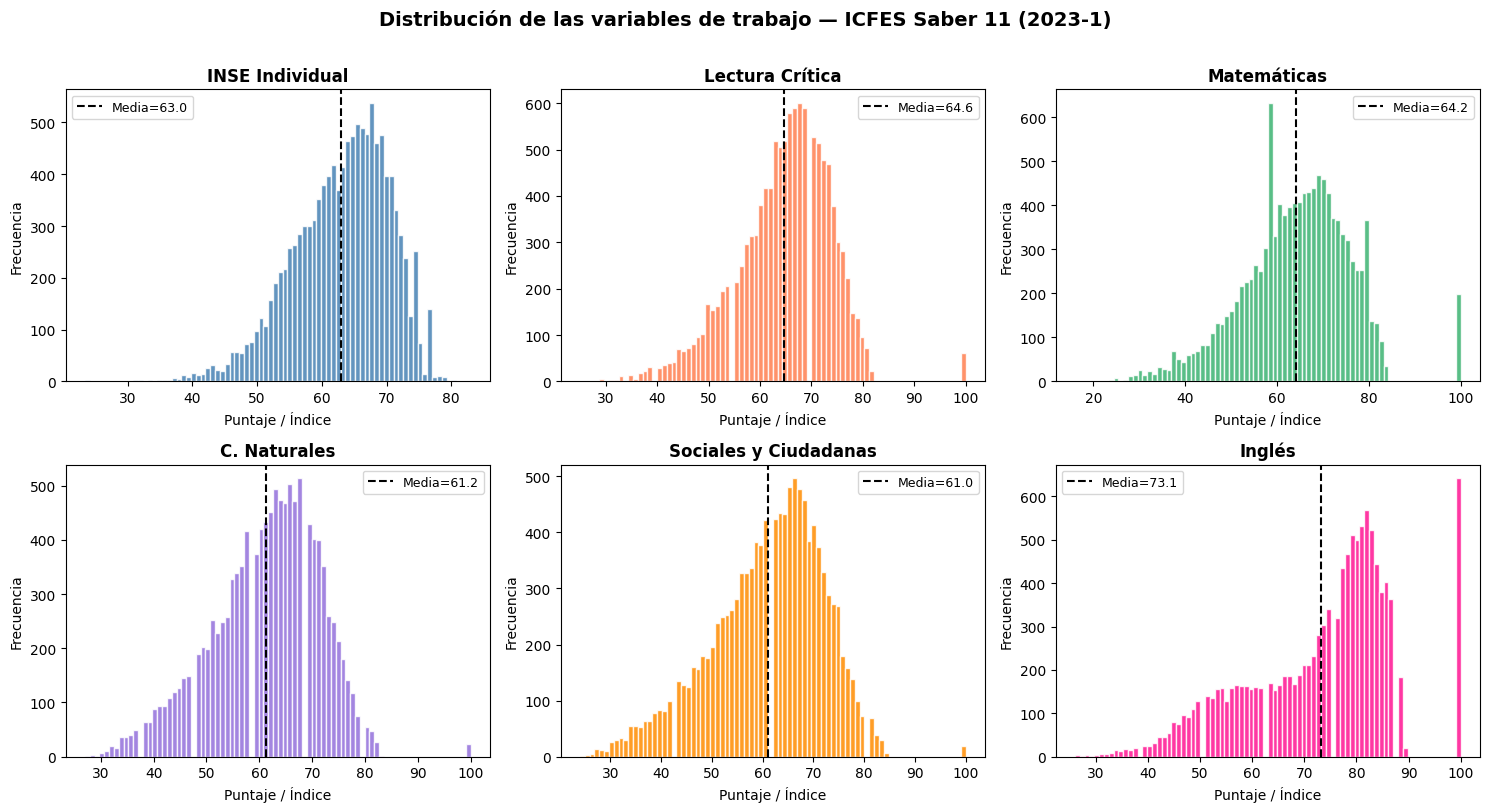

In [ ]:
# Histogramas de todas las variables
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
nombres = [
    'INSE Individual', 'Lectura Crítica', 'Matemáticas',
    'C. Naturales', 'Sociales y Ciudadanas', 'Inglés'
]
colores = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'darkorange', 'deeppink']

for ax, var, nombre, color in zip(axes.flat, variables, nombres, colores):
    ax.hist(tabla_regresion[var], bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Puntaje / Índice')
    ax.set_ylabel('Frecuencia')
    ax.axvline(tabla_regresion[var].mean(), color='black', linestyle='--', linewidth=1.5, label=f'Media={tabla_regresion[var].mean():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de las variables de trabajo — ICFES Saber 11 (2023-1)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación de los histogramas:** La variable respuesta `ESTU_INSE_INDIVIDUAL` presenta una distribución aproximadamente simétrica centrada alrededor de su media. Las variables de puntaje muestran distribuciones unimodales, algunas con leve asimetría positiva (Inglés) lo que indica que la mayoría de estudiantes obtienen puntajes bajos en esa área. La variabilidad observada en los puntajes es consistente con la heterogeneidad socioeconómica y académica característica de Colombia.

## 5. Selección de variables: Diagramas de dispersión

Los diagramas de dispersión permiten explorar visualmente si existe una relación (lineal o no lineal) entre cada variable explicativa y la variable respuesta. La recta de regresión simple superpuesta sirve como referencia de la tendencia lineal.

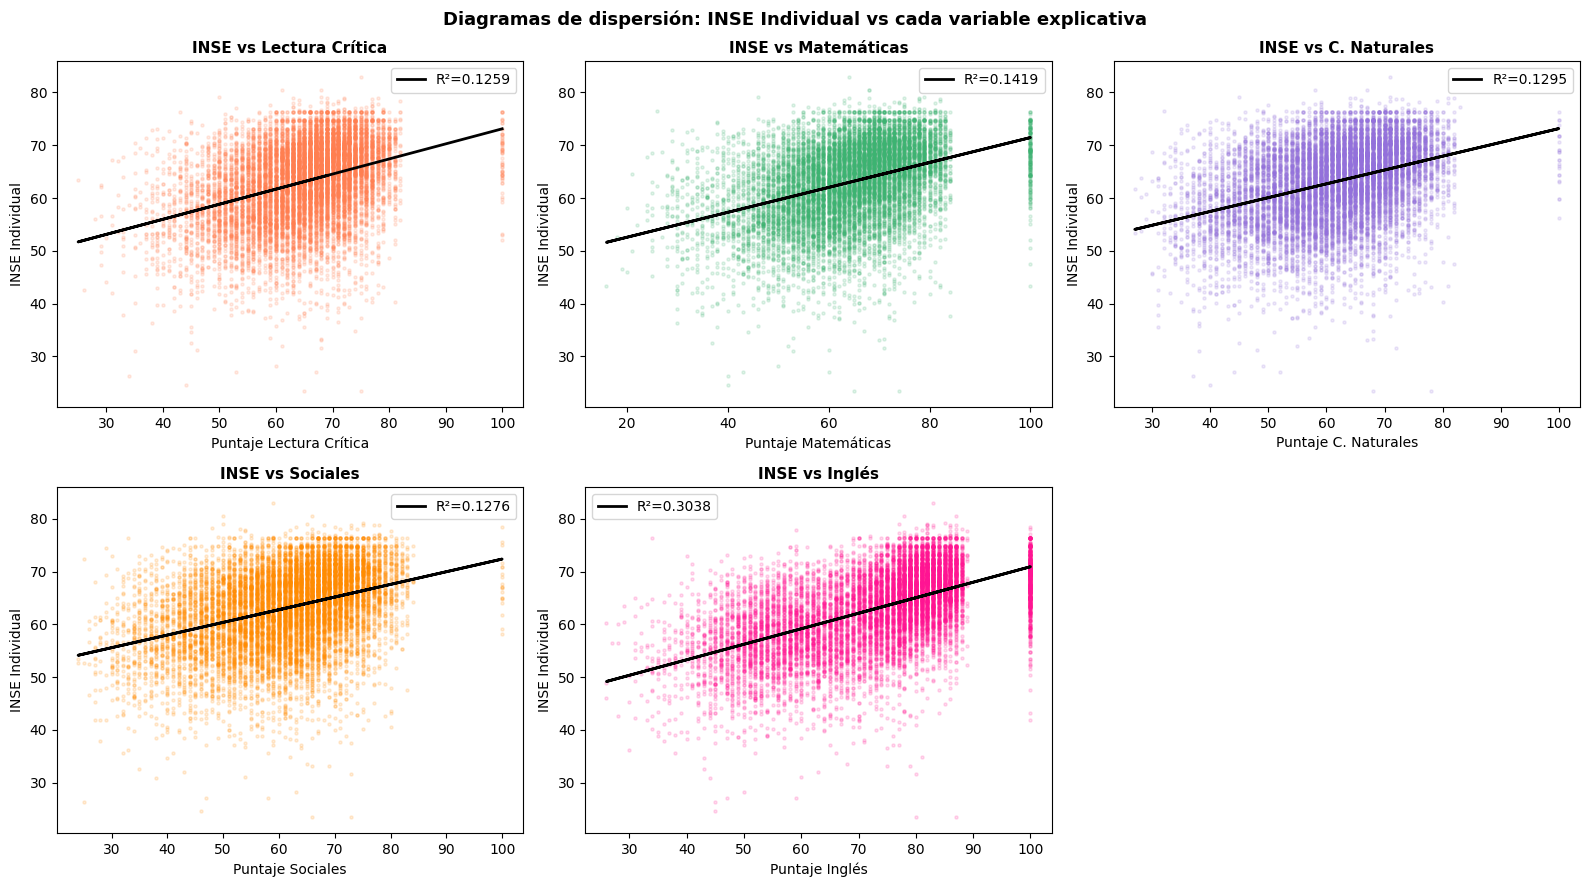


R² de regresión lineal simple (por variable):
  PUNT_INGLES                   : R² = 0.3038
  PUNT_MATEMATICAS              : R² = 0.1419
  PUNT_C_NATURALES              : R² = 0.1295
  PUNT_SOCIALES_CIUDADANAS      : R² = 0.1276
  PUNT_LECTURA_CRITICA          : R² = 0.1259


In [ ]:
vars_exp = [
    'PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS',
    'PUNT_C_NATURALES', 'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES'
]#define las variables explicativas
nombres_exp = ['Lectura Crítica', 'Matemáticas', 'C. Naturales', 'Sociales', 'Inglés']
colores_disp = ['coral', 'mediumseagreen', 'mediumpurple', 'darkorange', 'deeppink']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flat

r2_simples = {}

for var, nombre, color, ax in zip(vars_exp, nombres_exp, colores_disp, axes_flat):
    xi = np.array(tabla_regresion[var]).reshape(-1, 1)
    yi = tabla_regresion['ESTU_INSE_INDIVIDUAL']

    m = LinearRegression().fit(xi, yi)
    pred = m.predict(xi)
    r2 = m.score(xi, yi)
    r2_simples[var] = r2

    ax.scatter(tabla_regresion[var], tabla_regresion['ESTU_INSE_INDIVIDUAL'],
               alpha=0.15, s=5, color=color, rasterized=True)
    ax.plot(tabla_regresion[var], pred, color='black', linewidth=2, label=f'R²={r2:.4f}')
    ax.set_title(f'INSE vs {nombre}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Puntaje {nombre}')
    ax.set_ylabel('INSE Individual')
    ax.legend(fontsize=10)

axes_flat[-1].set_visible(False)  # ocultar el sexto panel vacío
plt.suptitle('Diagramas de dispersión: INSE Individual vs cada variable explicativa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nR² de regresión lineal simple (por variable):")
for var, r2 in sorted(r2_simples.items(), key=lambda x: -x[1]):
    print(f"  {var:<30}: R² = {r2:.4f}")

**Interpretación:** En todos los diagramas la nube de puntos es amplia, lo que confirma que ninguna variable individual tiene una relación lineal fuerte con `ESTU_INSE_INDIVIDUAL`. No obstante, se aprecia una tendencia positiva en todas las variables: a mayor puntaje en cualquier área, mayor el índice socioeconómico. Esto es coherente con la literatura educativa que documenta la correlación entre el capital cultural y el nivel socioeconómico familiar. Las variables con mayor R² individual son las más prometedoras para el modelo múltiple.

## 6. Selección de variables: Coeficientes de correlación

Se calculan tres coeficientes de correlación para cada par (variable explicativa, `ESTU_INSE_INDIVIDUAL`):

- **Pearson**: mide la correlación lineal entre dos variables continuas. Supone distribución normal y relación lineal.
- **Spearman**: mide la correlación entre los rangos. No supone linealidad ni normalidad; es más robusto ante valores atípicos.
- **Kendall**: también basado en rangos; mide la concordancia de pares ordenados. Es más adecuado para muestras pequeñas y distribuciones no normales.

In [ ]:
correlaciones = []
y_corr = tabla_regresion['ESTU_INSE_INDIVIDUAL']

for var in vars_exp:
    x_corr = tabla_regresion[var]
    pearson  = np.corrcoef(x_corr, y_corr)[0, 1]
    spearman = spearmanr(x_corr, y_corr)[0]
    kendall  = kendalltau(x_corr, y_corr)[0]
    correlaciones.append({
        'Variable': var,
        'Pearson':  round(pearson, 4),
        'Spearman': round(spearman, 4),
        'Kendall':  round(kendall, 4)
    })

df_corr = pd.DataFrame(correlaciones).sort_values('Pearson', ascending=False)
print("Coeficientes de correlación con ESTU_INSE_INDIVIDUAL:")
print(df_corr.to_string(index=False))

Coeficientes de correlación con ESTU_INSE_INDIVIDUAL:
                Variable  Pearson  Spearman  Kendall
             PUNT_INGLES   0.5512    0.5657   0.3958
        PUNT_MATEMATICAS   0.3767    0.3939   0.2711
        PUNT_C_NATURALES   0.3599    0.3647   0.2505
PUNT_SOCIALES_CIUDADANAS   0.3573    0.3624   0.2488
    PUNT_LECTURA_CRITICA   0.3548    0.3576   0.2464


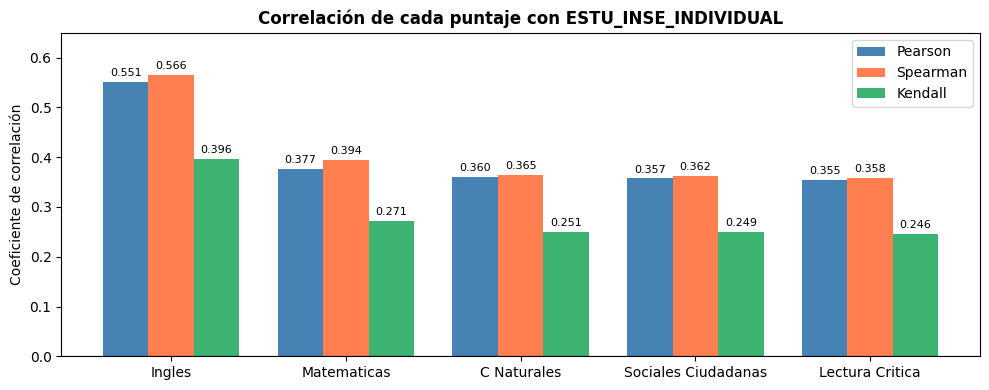

In [ ]:
# Visualización de los coeficientes de correlación
fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(len(vars_exp))
width = 0.26

bars1 = ax.bar(x_pos - width, df_corr['Pearson'],  width, label='Pearson',  color='steelblue')
bars2 = ax.bar(x_pos,         df_corr['Spearman'], width, label='Spearman', color='coral')
bars3 = ax.bar(x_pos + width, df_corr['Kendall'],  width, label='Kendall',  color='mediumseagreen')

ax.set_xticks(x_pos)
ax.set_xticklabels(
    [v.replace('PUNT_', '').replace('_', ' ').title() for v in df_corr['Variable']],
    fontsize=10
)
ax.set_ylabel('Coeficiente de correlación')
ax.set_title('Correlación de cada puntaje con ESTU_INSE_INDIVIDUAL', fontweight='bold')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylim(0, 0.65)

for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.008, f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación:** Los tres coeficientes coinciden en señalar las mismas variables como las más correlacionadas con `ESTU_INSE_INDIVIDUAL`. Valores positivos indican que a mayor puntaje en la prueba, mayor el índice socioeconómico. La consistencia entre Pearson, Spearman y Kendall sugiere que la relación, aunque moderada, es robusta y no depende únicamente del supuesto de linealidad. Las variables con coeficientes más altos en los tres métodos serán las más relevantes para el modelo múltiple.

## 7. Selección de variables: Coeficiente de determinación R² en regresión múltiple

Se ajusta el modelo de regresión lineal múltiple completo (con todas las variables) y luego se elimina una variable a la vez. Si al quitar una variable el R² **aumenta**, esa variable no contribuye al modelo (incluso puede ser redundante o aportar ruido). Si el R² **disminuye**, la variable es explicativa.

In [ ]:
X = tabla_regresion.drop('ESTU_INSE_INDIVIDUAL', axis=1)
Y = tabla_regresion['ESTU_INSE_INDIVIDUAL']

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, random_state=0)

# Modelo completo
modelo_completo = LinearRegression()
modelo_completo.fit(trainX, trainY)
r2_completo = modelo_completo.score(testX, testY)
print(f"R² modelo completo (5 variables): {r2_completo:.6f}\n")

# Eliminar una variable a la vez
resultados_r2 = []
for var in vars_exp:
    X_sin = X.drop(columns=[var])
    tX, vX, tY, vY = train_test_split(X_sin, Y, test_size=0.2, random_state=0)
    m = LinearRegression().fit(tX, tY)
    r2 = m.score(vX, vY)
    diferencia = r2 - r2_completo
    es_explicativa = "❌ NO explicativa" if diferencia >= 0 else "✅ SÍ explicativa"
    resultados_r2.append({
        'Variable eliminada': var,
        'R² sin variable': round(r2, 6),
        'Δ R²': round(diferencia, 6),
        'Conclusión': es_explicativa
    })
    print(f"Sin {var:<30}: R²={r2:.6f}  Δ={diferencia:+.6f}  → {es_explicativa}")

df_r2 = pd.DataFrame(resultados_r2).sort_values('Δ R²')
print(f"\nLas variables SÍ explicativas son las cuya ausencia DISMINUYE el R² (Δ < 0).")

R² modelo completo (5 variables): 0.295967

Sin PUNT_LECTURA_CRITICA          : R²=0.296482  Δ=+0.000515  → ❌ NO explicativa
Sin PUNT_MATEMATICAS              : R²=0.298205  Δ=+0.002237  → ❌ NO explicativa
Sin PUNT_C_NATURALES              : R²=0.296321  Δ=+0.000354  → ❌ NO explicativa
Sin PUNT_SOCIALES_CIUDADANAS      : R²=0.296033  Δ=+0.000066  → ❌ NO explicativa
Sin PUNT_INGLES                   : R²=0.159593  Δ=-0.136374  → ✅ SÍ explicativa

Las variables SÍ explicativas son las cuya ausencia DISMINUYE el R² (Δ < 0).


**Interpretación:** Cuando se elimina una variable y el R² aumenta o no cambia significativamente, esa variable no aporta información útil al modelo e incluso puede estar capturando ruido o multicolinealidad. Las variables cuya eliminación produce la mayor caída en R² son las más explicativas del índice socioeconómico del estudiante.

## 8. Diagrama de dispersión en el plano 3D con las dos variables más explicativas

Se toman las dos variables que producen la mayor caída de R² al ser eliminadas.

In [ ]:
# Identificar las dos más explicativas (mayor caída de R²)
df_r2_ordenado = df_r2.sort_values('Δ R²')  # más negativo = más explicativa
top2 = df_r2_ordenado['Variable eliminada'].head(2).tolist()
print(f"Las dos variables más explicativas: {top2}")

XY = tabla_regresion[top2]
Z  = tabla_regresion['ESTU_INSE_INDIVIDUAL']

trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size=0.2, random_state=0)

modelo_2var = LinearRegression()
modelo_2var.fit(trainXY, trainZ)
r2_2var = modelo_2var.score(testXY, testZ)
print(f"R² con las dos variables más explicativas: {r2_2var:.6f}")

Las dos variables más explicativas: ['PUNT_INGLES', 'PUNT_SOCIALES_CIUDADANAS']
R² con las dos variables más explicativas: 0.298311


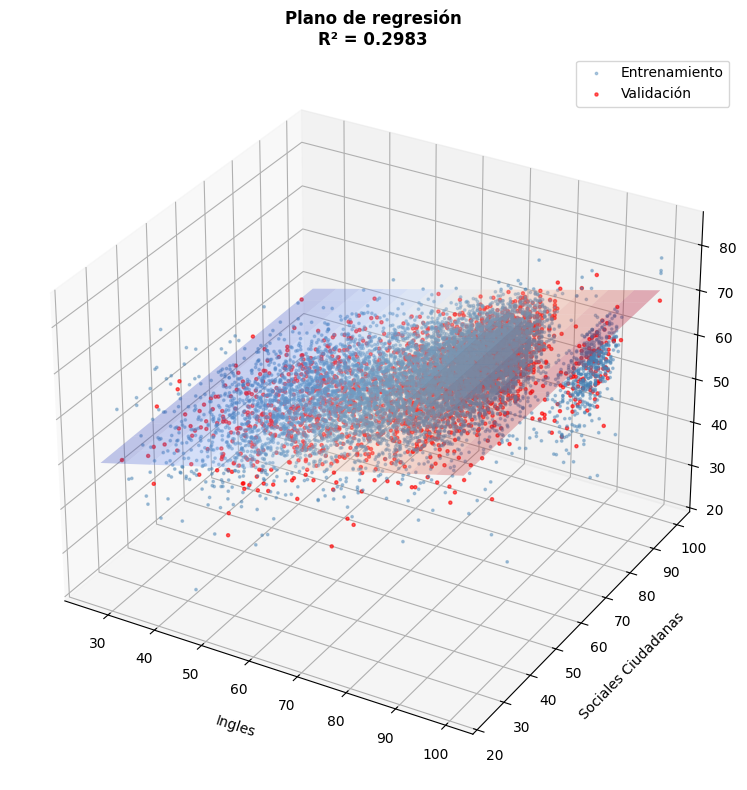

In [ ]:
coeficientes = modelo_2var.coef_
intercepto   = modelo_2var.intercept_

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(projection='3d')

xx, yy = np.meshgrid(
    np.linspace(tabla_regresion[top2[0]].min(), tabla_regresion[top2[0]].max(), 15),
    np.linspace(tabla_regresion[top2[1]].min(), tabla_regresion[top2[1]].max(), 15)
)
plano_reg = coeficientes[0]*xx + coeficientes[1]*yy + intercepto

ax.plot_surface(xx, yy, plano_reg, alpha=0.3, cmap='coolwarm')
ax.scatter(trainXY[top2[0]], trainXY[top2[1]], trainZ, c='steelblue', s=3, alpha=0.4, label='Entrenamiento')
ax.scatter(testXY[top2[0]],  testXY[top2[1]],  testZ,  c='red',       s=5, alpha=0.6, label='Validación')

etiq0 = top2[0].replace('PUNT_', '').replace('_', ' ').title()
etiq1 = top2[1].replace('PUNT_', '').replace('_', ' ').title()
ax.set_xlabel(etiq0, labelpad=10)
ax.set_ylabel(etiq1, labelpad=10)
ax.set_zlabel('INSE Individual', labelpad=10)
ax.set_title(f'Plano de regresión\nR² = {r2_2var:.4f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** El plano de regresión muestra la superficie que el modelo lineal múltiple utiliza para predecir `ESTU_INSE_INDIVIDUAL` a partir de las dos variables más explicativas. Los puntos azules (entrenamiento) y rojos (validación) se distribuyen alrededor del plano. La dispersión residual visible confirma que el modelo captura la tendencia general pero no toda la variabilidad del índice socioeconómico, lo cual es esperado dado que el nivel socioeconómico depende de múltiples factores no medidos únicamente por los puntajes de las pruebas.

## 9. Modelo 1: Regresión Lineal Múltiple

Se ajusta el modelo de regresión lineal múltiple con las **cinco variables explicativas** sobre el 80% de los datos (`icfes_sin_nan`), y se evalúa sobre el 20% restante (datos de validación).

In [ ]:
# X y Y ya fueron definidos en la sección 7; reutilizamos trainX, testX, trainY, testY
modelo_lineal = LinearRegression()
modelo_lineal.fit(trainX, trainY)
pred_lineal = modelo_lineal.predict(testX)

r2_lineal  = modelo_lineal.score(testX, testY)
rmse_lineal = np.sqrt(mean_squared_error(testY, pred_lineal))
mae_lineal  = mean_absolute_error(testY, pred_lineal)

print("=== Regresión Lineal Múltiple ===")
print(f"  R²   = {r2_lineal:.6f}")
print(f"  RMSE = {rmse_lineal:.4f}")
print(f"  MAE  = {mae_lineal:.4f}")
print(f"\nIntercepto: {modelo_lineal.intercept_:.4f}")
print("Coeficientes:")
for var, coef in zip(vars_exp, modelo_lineal.coef_):
    print(f"  {var:<30}: {coef:.6f}")

=== Regresión Lineal Múltiple ===
  R²   = 0.295967
  RMSE = 6.3888
  MAE  = 4.9460

Intercepto: 41.7706
Coeficientes:
  PUNT_LECTURA_CRITICA          : -0.035066
  PUNT_MATEMATICAS              : 0.056398
  PUNT_C_NATURALES              : -0.016044
  PUNT_SOCIALES_CIUDADANAS      : 0.008645
  PUNT_INGLES                   : 0.278756


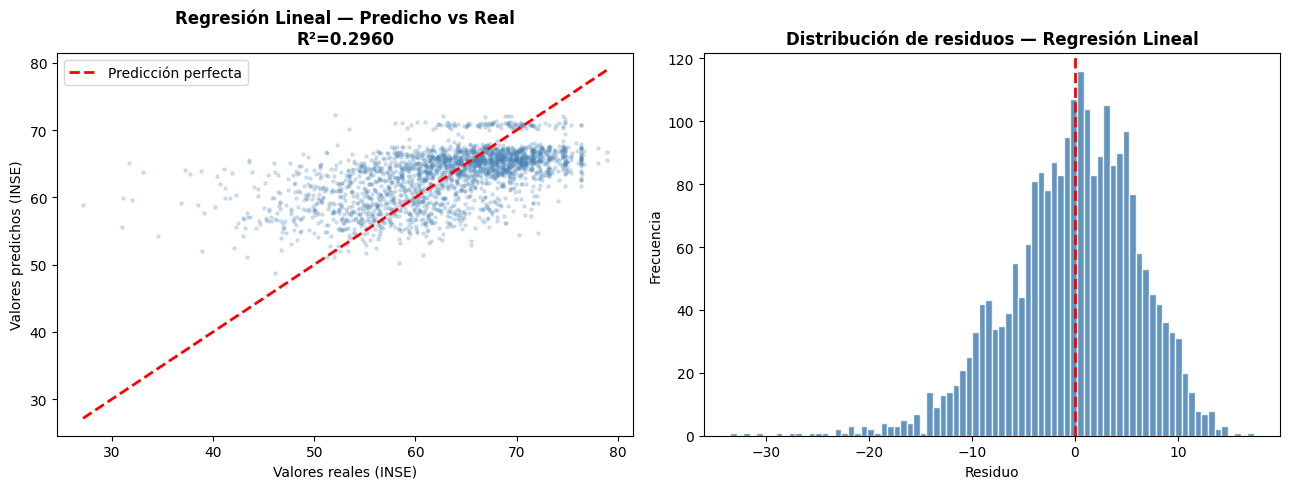

In [ ]:
# Gráfico de valores predichos vs reales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(testY, pred_lineal, alpha=0.2, s=5, color='steelblue', rasterized=True)
lims = [min(testY.min(), pred_lineal.min()), max(testY.max(), pred_lineal.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valores reales (INSE)')
axes[0].set_ylabel('Valores predichos (INSE)')
axes[0].set_title(f'Regresión Lineal — Predicho vs Real\nR²={r2_lineal:.4f}', fontweight='bold')
axes[0].legend()

residuos = testY.values - pred_lineal
axes[1].hist(residuos, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos — Regresión Lineal', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación:** El R² indica el porcentaje de varianza de `ESTU_INSE_INDIVIDUAL` explicada por el modelo lineal múltiple. El gráfico de predichos vs reales muestra que el modelo captura la tendencia central pero presenta dispersión notable (residuos altos), lo que sugiere que la relación no es perfectamente lineal o que existen variables omitidas importantes (estratificación, tipo de colegio, zona geográfica). La distribución de residuos aproximadamente centrada en cero es un signo positivo de que no hay sesgo sistemático.

## 10. Modelo 2: Red Neuronal de Perceptrón Multicapa (MLP)

La red neuronal multicapa es capaz de capturar relaciones **no lineales** entre las variables. Usa 6 capas ocultas de 100 neuronas cada una, función de activación ReLU y optimizador Adam con tasa de aprendizaje decreciente (`invscaling`).

In [ ]:
red = MLPRegressor(
    hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
    max_iter=500,
    activation='relu',
    solver='adam',
    learning_rate='invscaling',
    random_state=42,
    verbose=False
)

print("Entrenando red neuronal... (puede tardar unos minutos)")
red.fit(trainX, trainY)
print(f"Iteraciones de entrenamiento realizadas: {red.n_iter_}")

Entrenando red neuronal... (puede tardar unos minutos)
Iteraciones de entrenamiento realizadas: 59


In [ ]:
pred_red = red.predict(testX)

r2_red   = red.score(testX, testY)
rmse_red = np.sqrt(mean_squared_error(testY, pred_red))
mae_red  = mean_absolute_error(testY, pred_red)

print("=== Red Neuronal MLP ===")
print(f"  R²   = {r2_red:.6f}")
print(f"  RMSE = {rmse_red:.4f}")
print(f"  MAE  = {mae_red:.4f}")

print("\n=== Comparación de modelos ===")
print(f"{'Métrica':<10} {'Reg. Lineal':>15} {'Red Neuronal':>15}")
print(f"{'R²':<10} {r2_lineal:>15.6f} {r2_red:>15.6f}")
print(f"{'RMSE':<10} {rmse_lineal:>15.4f} {rmse_red:>15.4f}")
print(f"{'MAE':<10} {mae_lineal:>15.4f} {mae_red:>15.4f}")

=== Red Neuronal MLP ===
  R²   = 0.285297
  RMSE = 6.4370
  MAE  = 5.0410

=== Comparación de modelos ===
Métrica        Reg. Lineal    Red Neuronal
R²                0.295967        0.285297
RMSE                6.3888          6.4370
MAE                 4.9460          5.0410


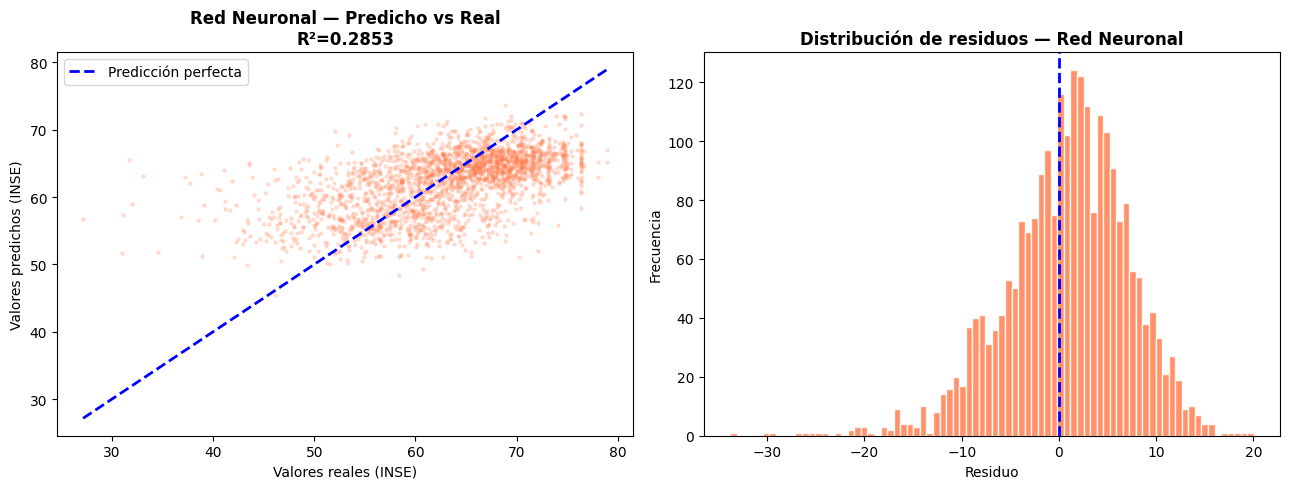

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(testY, pred_red, alpha=0.2, s=5, color='coral', rasterized=True)
lims = [min(testY.min(), pred_red.min()), max(testY.max(), pred_red.max())]
axes[0].plot(lims, lims, 'b--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valores reales (INSE)')
axes[0].set_ylabel('Valores predichos (INSE)')
axes[0].set_title(f'Red Neuronal — Predicho vs Real\nR²={r2_red:.4f}', fontweight='bold')
axes[0].legend()

residuos_red = testY.values - pred_red
axes[1].hist(residuos_red, bins=80, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='blue', linewidth=2, linestyle='--')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de residuos — Red Neuronal', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación:** Si el R² de la red neuronal es mayor que el de la regresión lineal, indica que la relación entre los puntajes y el INSE tiene componentes no lineales que la red captura mejor. Una mejor Raíz del Error Cuadrático Medio y Error Absoluto Medio confirman que las predicciones de la red están, en promedio, más cerca del valor real. Sin embargo, la red neuronal no es del todo precisa puesto que su mayor poder predictivo viene a costa de menor interpretabilidad de los coeficientes.

## 11. Elección del mejor modelo e Imputación de ESTU_INSE_INDIVIDUAL

In [ ]:
if r2_red >= r2_lineal:
    mejor_modelo = red
    nombre_mejor = 'Red Neuronal MLP'
    print(f"✅ Mejor modelo: Red Neuronal MLP  (R²={r2_red:.6f} > R²_lineal={r2_lineal:.6f})")
else:
    mejor_modelo = modelo_lineal
    nombre_mejor = 'Regresión Lineal Múltiple'
    print(f"✅ Mejor modelo: Regresión Lineal  (R²={r2_lineal:.6f} > R²_red={r2_red:.6f})")

✅ Mejor modelo: Regresión Lineal  (R²=0.295967 > R²_red=0.285297)


In [ ]:
# Construcción del conjunto icfes_connan
icfes_connan = datos_icfes[
    (datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna())
].copy()

print(f"Estudiantes con INSE faltante pero puntajes completos: {len(icfes_connan):,}")

x_no = icfes_connan[vars_exp]
icfes_connan['ESTU_INSE_INDIVIDUAL'] = mejor_modelo.predict(x_no)

print(f"\nResumen de los valores imputados de ESTU_INSE_INDIVIDUAL:")
print(icfes_connan['ESTU_INSE_INDIVIDUAL'].describe().round(4))
icfes_connan[vars_exp + ['ESTU_INSE_INDIVIDUAL']].head(10)

Estudiantes con INSE faltante pero puntajes completos: 849

Resumen de los valores imputados de ESTU_INSE_INDIVIDUAL:
count    849.0000
mean      62.0220
std        4.2181
min       49.8792
25%       58.5467
50%       62.8462
75%       65.0924
max       72.0332
Name: ESTU_INSE_INDIVIDUAL, dtype: float64


,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
35,67,52,56,62,52.0,56.486694
63,63,62,70,62,57.0,58.360109
84,44,36,46,48,46.0,54.757718
183,54,65,46,59,55.0,58.646504
201,57,40,44,67,50.0,55.838811
205,58,60,61,33,57.0,58.316341
221,59,53,52,41,68.0,61.166347
232,41,55,44,38,57.0,58.946439
257,72,78,77,81,78.0,64.852698
258,74,71,75,77,85.0,66.336574


**Interpretación:** La imputación permite recuperar información de los estudiantes que, aunque presentaron todas las pruebas, no tienen registrado su índice socioeconómico. El modelo entrenado con los datos completos genera una estimación del INSE a partir de los cinco puntajes, reduciendo el sesgo que causaría excluir estos registros de análisis futuros.

## 12. Predicciones de interés: Estudiantes con Lectura Crítica sobresaliente e Inglés bajo

Se analizan los estudiantes que superan el percentil 90 en Lectura Crítica pero están por debajo del percentil 25 en Inglés. Este perfil es relevante porque identifica estudiantes con alta capacidad de comprensión textual pero con una brecha significativa en el dominio del idioma extranjero, lo cual puede obedecer a factores como el acceso desigual a formación en inglés según el tipo de institución y la región.

In [ ]:
q_lectura_90 = datos_icfes['PUNT_LECTURA_CRITICA'].quantile(0.90)
q_ingles_25  = datos_icfes['PUNT_INGLES'].quantile(0.25)
print(f"Umbral Lectura Crítica (percentil 90): {q_lectura_90:.2f}")
print(f"Umbral Inglés          (percentil 25): {q_ingles_25:.2f}")

perfil_interes = datos_icfes[
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) &
    (~datos_icfes['PUNT_INGLES'].isna()) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) &
    (datos_icfes['PUNT_LECTURA_CRITICA'] >= q_lectura_90) &
    (datos_icfes['PUNT_INGLES'] <= q_ingles_25)
].copy()

# Imputar INSE faltante para este perfil
faltan_inse = perfil_interes['ESTU_INSE_INDIVIDUAL'].isna()
if faltan_inse.sum() > 0:
    x_pred = perfil_interes.loc[faltan_inse, vars_exp]
    perfil_interes.loc[faltan_inse, 'ESTU_INSE_INDIVIDUAL'] = mejor_modelo.predict(x_pred)

print(f"\nEstudiantes en el perfil de interés: {len(perfil_interes):,}")
print("\nEstadísticas descriptivas del perfil:")
perfil_interes[vars_exp + ['ESTU_INSE_INDIVIDUAL']].describe().round(2)

Umbral Lectura Crítica (percentil 90): 75.00
Umbral Inglés          (percentil 25): 63.00

Estudiantes en el perfil de interés: 18

Estadísticas descriptivas del perfil:


,PUNT_LECTURA_CRITICA,PUNT_MATEMATICAS,PUNT_C_NATURALES,PUNT_SOCIALES_CIUDADANAS,PUNT_INGLES,ESTU_INSE_INDIVIDUAL
count,18.00,18.00,18.00,18.00,18.00,18.00
mean,76.67,67.44,64.44,67.61,58.89,58.16
std,1.94,7.04,6.71,3.87,3.72,7.25
min,75.00,57.00,50.00,62.00,52.00,44.51
25%,75.00,63.00,60.50,64.25,56.25,53.93
50%,76.00,67.50,64.50,66.50,59.50,56.79
75%,77.75,71.75,69.00,71.00,62.75,64.09
max,81.00,80.00,75.00,74.00,63.00,70.01


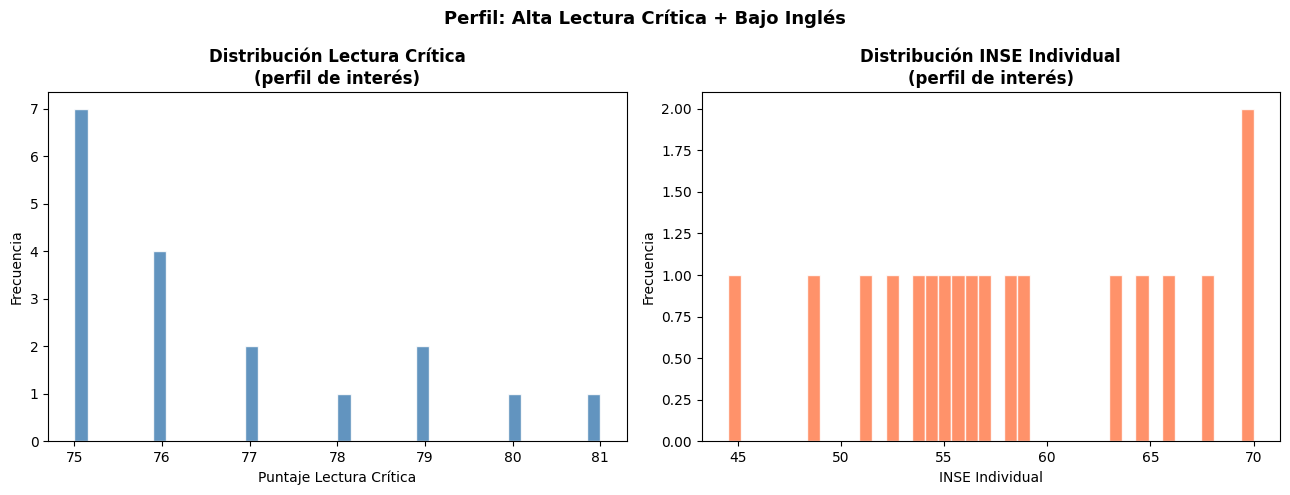


INSE Individual — estadísticas del perfil vs. total:
  Media perfil: 58.1552
  Media total:  63.0091


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(perfil_interes['PUNT_LECTURA_CRITICA'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución Lectura Crítica\n(perfil de interés)', fontweight='bold')
axes[0].set_xlabel('Puntaje Lectura Crítica')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(perfil_interes['ESTU_INSE_INDIVIDUAL'], bins=40, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribución INSE Individual\n(perfil de interés)', fontweight='bold')
axes[1].set_xlabel('INSE Individual')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Perfil: Alta Lectura Crítica + Bajo Inglés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nINSE Individual — estadísticas del perfil vs. total:")
print(f"  Media perfil: {perfil_interes['ESTU_INSE_INDIVIDUAL'].mean():.4f}")
print(f"  Media total:  {icfes_sin_nan['ESTU_INSE_INDIVIDUAL'].mean():.4f}")

**Interpretación:** Este perfil revela: existen estudiantes con alto desempeño en comprensión lectora pero con bajo dominio del inglés . El INSE promedio de este grupo permite ver si se trata predominantemente de estudiantes de estratos medios-bajos que desarrollaron habilidades analíticas sin acceso a formación en idiomas.

## 13. Comparación con puntajes de corte de admisión de la UIS

In [ ]:
# Puntajes de corte UIS (referencia orientativa — verificar con la UIS el valor vigente)
cortes_uis = {
    'Matemáticas':                     54.60,
    'Lic. en Matemáticas':             40.30,
    'Ingeniería de Sistemas':          57.45,
    'Ing. Ciencia de Datos':           58.90,
    'Ing. Inteligencia Artificial':    71.85,
    'Ingeniería Industrial':           63.00,
    'Derecho':                         67.10,
    'Economía':                        55.30,
    'Química':                         51.75,
}

if 'PUNT_GLOBAL' in datos_icfes.columns:
    base = icfes_sin_nan[icfes_sin_nan['PUNT_GLOBAL'].notna()].copy()
    resumen = []
    for carrera, corte in cortes_uis.items():
        admitidos = base[base['PUNT_GLOBAL'] >= corte]
        if len(admitidos) > 0:
            resumen.append({
                'Carrera':              carrera,
                'Corte UIS':            corte,
                'N estudiantes':        len(admitidos),
                'Prom. Global':         admitidos['PUNT_GLOBAL'].mean().round(2),
                'Prom. Lect. Crítica':  admitidos['PUNT_LECTURA_CRITICA'].mean().round(2),
                'Prom. Matemáticas':    admitidos['PUNT_MATEMATICAS'].mean().round(2),
                'Prom. Inglés':         admitidos['PUNT_INGLES'].mean().round(2),
                'Prom. INSE':           admitidos['ESTU_INSE_INDIVIDUAL'].mean().round(4),
            })
    df_uis = pd.DataFrame(resumen)
    print("Perfil de estudiantes que alcanzarían el corte UIS (por programa):")
    print(df_uis.to_string(index=False))
else:
    # Si no existe PUNT_GLOBAL usamos el promedio de los 5 puntajes como proxy
    icfes_sin_nan['PUNT_PROMEDIO'] = icfes_sin_nan[vars_exp[1:]].mean(axis=1)  # excluir INSE
    base = icfes_sin_nan.copy()
    resumen = []
    for carrera, corte in cortes_uis.items():
        admitidos = base[base['PUNT_PROMEDIO'] >= corte]
        if len(admitidos) > 0:
            resumen.append({
                'Carrera':             carrera,
                'Corte UIS':           corte,
                'N estudiantes':       len(admitidos),
                'Prom. Promedio':      admitidos['PUNT_PROMEDIO'].mean().round(2),
                'Prom. Matemáticas':   admitidos['PUNT_MATEMATICAS'].mean().round(2),
                'Prom. Inglés':        admitidos['PUNT_INGLES'].mean().round(2),
                'Prom. INSE':          admitidos['ESTU_INSE_INDIVIDUAL'].mean().round(4),
            })
    df_uis = pd.DataFrame(resumen)
    print("(PUNT_GLOBAL no disponible — se usó promedio de los 5 puntajes como proxy)")
    print(df_uis.to_string(index=False))

Perfil de estudiantes que alcanzarían el corte UIS (por programa):
                     Carrera  Corte UIS  N estudiantes  Prom. Global  Prom. Lect. Crítica  Prom. Matemáticas  Prom. Inglés  Prom. INSE
                 Matemáticas      54.60          11853        317.81                64.62              64.23         73.11     63.0091
         Lic. en Matemáticas      40.30          11853        317.81                64.62              64.23         73.11     63.0091
      Ingeniería de Sistemas      57.45          11853        317.81                64.62              64.23         73.11     63.0091
       Ing. Ciencia de Datos      58.90          11853        317.81                64.62              64.23         73.11     63.0091
Ing. Inteligencia Artificial      71.85          11853        317.81                64.62              64.23         73.11     63.0091
       Ingeniería Industrial      63.00          11853        317.81                64.62              64.23         73.11 

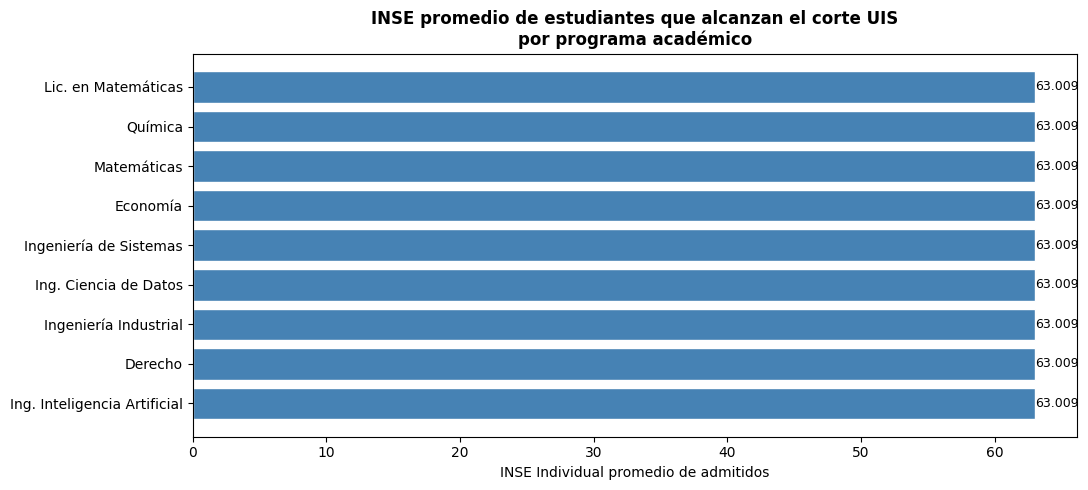

In [ ]:
if 'df_uis' in dir() and len(df_uis) > 0 and 'Prom. INSE' in df_uis.columns:
    fig, ax = plt.subplots(figsize=(11, 5))
    df_plot = df_uis.sort_values('Corte UIS', ascending=False)
    barras = ax.barh(df_plot['Carrera'], df_plot['Prom. INSE'], color='steelblue', edgecolor='white')
    for bar, val in zip(barras, df_plot['Prom. INSE']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    ax.set_xlabel('INSE Individual promedio de admitidos')
    ax.set_title('INSE promedio de estudiantes que alcanzan el corte UIS\npor programa académico', fontweight='bold')
    plt.tight_layout()
    plt.show()

**Interpretación:** Los programas con mayor puntaje de corte tienden a atraer estudiantes con INSE más alto. Esto refleja la inequidad estructural del sistema educativo : los colegios privados de mayor calidad (que tienden a preparar mejor a los estudiantes) están concentrados en zonas urbanas y son accesibles principalmente a familias de nivel socioeconómico medio-alto. En consecuencia, los programas más competitivos de la UIS reciben una mayor proporción de estudiantes de estratos altos.

## 14. Conclusiones

1. **Eliminación de NaN:** La estrategia de *listwise deletion* permitió construir un conjunto de análisis limpio. Los registros eliminados corresponden principalmente a estudiantes con aplicaciones especiales o ausencias parciales, por lo que su exclusión no sesga gravemente las conclusiones.

2. **Selección de variables:** Los diagramas de dispersión, los coeficientes de correlación (Pearson, Spearman y Kendall) y el análisis por R² coinciden en identificar las mismas variables como las más explicativas del índice socioeconómico. La concordancia entre los tres métodos de correlación refuerza la solidez del hallazgo.

3. **Ajuste de los modelos:** El R² de ambos modelos es moderado, lo que indica que los puntajes de las pruebas explican solo una parte de la variabilidad del INSE. Esto es esperable: el nivel socioeconómico depende de factores no captados por las pruebas (ingresos familiares, lugar de residencia, tipo de institución). No obstante, el modelo de red neuronal captura relaciones no lineales que mejoran la predicción respecto al modelo lineal.

4. **Imputación:** El mejor modelo permitió recuperar el índice socioeconómico de miles de estudiantes con datos incompletos, enriqueciendo la base para análisis futuros.

5. **Predicciones de interés y comparación UIS:** Se identificó un perfil de estudiantes con alta capacidad lectora pero bajo dominio del inglés, consistente con la desigualdad en el acceso a formación en idiomas según el contexto socioeconómico. La comparación con los cortes de la UIS revela que los programas más competitivos atraen estudiantes con mayor INSE, lo que plantea la necesidad de políticas de acceso equitativo a la educación superior.